In [42]:
import sympy as sp
import numpy as np
from IPython.display import display, Math,Markdown
from importlib import reload
import matplotlib.pyplot as plt
## Custom functions
import FockSystem.FockSystem as fst
reload(fst)
def print_md(item):
    display(Markdown(item._repr_markdown_()))


c_down = fst.OperSequence([0])
c_up = fst.OperSequence([2])
a_down = ~c_down
a_up = ~c_up

zero = fst.Zero
a0 = sp.Symbol('a_0', real=False, positive=False)

In [43]:
def extra_deep_scrub(op):
    for idx in range(len(op.weights)-1, -1,-1):
        if op.weights[idx].round(14).is_zero:
            op.weights.pop(idx)
            op.oper_list.pop(idx)

# Define a threshold for "small" numbers
threshold = 1e-12

def clean_complex(z, tol=threshold):
    z = sp.expand(z)
    re = 0.0 if abs(sp.re(z)) < tol else sp.re(z)
    im = 0.0 if abs(sp.im(z)) < tol else sp.im(z)
    return complex(re, im)
    
def test_solution(paraferm):
    ### Test gamma^3 = 1
    cube = paraferm**3
    for idx,w in enumerate(cube.weights):
        cube.weights[idx] = clean_complex(sp.simplify(w))
    cube.remove_zero_weight()
    #extra_deep_scrub(cube)
    is_unity = (cube==P)
    display(Markdown('$\\chi^3$ = ' + cube._repr_markdown_() + f' ({is_unity})'))

    ### Test gamma^2 = gamma^dagger
    conj = ~paraferm
    conj.normal_order()
    conj
    for idx,w in enumerate(conj.weights):
        conj.weights[idx] = sp.simplify(sp.expand(w))
    conj.remove_zero_weight()

    sq = paraferm**2
    for idx,w in enumerate(sq.weights):
        sq.weights[idx] = sp.simplify(sp.expand(w))
    sq.remove_zero_weight()
    is_hermit = (sq == conj)
    display(Markdown('$\\chi^2$ = $\\chi^{\\dagger}$' + f' ({is_hermit})'))

def test_solutions(paraferm_vec1, paraferm_vec2):
    if not isinstance(paraferm_vec1,fst.OperSequence):
        u = make_oper(paraferm_vec1)
        v = make_oper(paraferm_vec2)
    else:
        u = paraferm_vec1
        v = paraferm_vec2
    print('Operator 1:')
    test_solution(u)
    
    print('Operator 2:')
    test_solution(v)

    comm = (u)*(v) - omega*(v)*u
    for idx,w in enumerate(comm.weights):
        comm.weights[idx] = sp.simplify(w)
    comm.remove_zero_weight()
    print('Commutator:')
    if comm == zero:
        display(Markdown('$\\chi_1\\chi_2 - \\omega\\chi_2\\chi_1=0$'))
    else:
        print('Commutation FAILED')


def test_solutions_matr(paraferm_matr1, paraferm_matr2):
    u = matrix_to_operator(paraferm_matr1)
    v = matrix_to_operator(paraferm_matr2)
    print('Operator 1:')
    test_solution(u)
    
    print('Operator 2:')
    test_solution(v)

    comm = (u)*(v) - omega*(v)*u
    for idx,w in enumerate(comm.weights):
        comm.weights[idx] = sp.simplify(sp.expand(w))
    comm.remove_zero_weight()
    print('Commutator:')
    if comm == zero:
        display(Markdown('$\\chi_1\\chi_2 - \\omega\\chi_2\\chi_1=0$'))
    else:
        print_md(comm)
        print('Commutation FAILED')
    return u,v

def test_solution_W(W):
    U_prime = sp.simplify(W.H*U*W)
    V_prime = sp.simplify(W.H*V*W)
    u,v = test_solutions_matr(U_prime,V_prime)
    return u,v

def make_oper(vector):
    oper = fst.OperSequence()
    for idx,v in enumerate(vector):
        oper+= v*constr_seqs[idx]
    oper.remove_zero_weight()
    return oper

def odd_even_split(oper):
    oper_list_even = []
    oper_list_odd = []
    weight_list_even = []
    weight_list_odd = []
    for idx,w in enumerate(oper.oper_list):
        if len(w) % 2:
            oper_list_odd.append(w)
            weight_list_odd.append(oper.weights[idx])
        else:
            oper_list_even.append(w)
            weight_list_even.append(oper.weights[idx])

    even_op = fst.OperSequence(oper_list_even, weights=weight_list_even,bypass_parse=True)
    odd_op = fst.OperSequence(oper_list_odd, weights=weight_list_odd,bypass_parse=True)
    return even_op, odd_op

omega = sp.nsimplify(sp.exp(2*sp.pi*sp.I/3))

In [44]:
## Initial U and V matrices
U = sp.Matrix(3, 3, lambda i, j: 0)
U[0,1] = 1
U[1,2] = 1
U[2,0] = 1

V = sp.Matrix(3, 3, lambda i, j: 0)
V[0,0] = 1
V[1,1] = omega
V[2,2] = omega**2

In [45]:
n_up = c_up*a_up
n_down = c_down*a_down
P = -c_down*a_down*c_up*a_up+1

base_vec = [
    [P*(-n_up-n_down+1)*P, P*a_down*P, P*a_up*P],
     [P*c_down*P ,P*n_down*P , P*c_down*a_up*P],
     [P*c_up*P, P*c_up*a_down*P , P*n_up*P],
]
def matrix_to_operator(matrix):
    oper = fst.OperSequence()
    for i in range(3):
        for j in range(3):
            oper+= matrix[i,j]*base_vec[i][j]
    oper.remove_zero_weight()
    return oper

def show_solution(W):
    U_prime = sp.simplify(W.H*U*W)
    V_prime = sp.simplify(W.H*V*W)
    u = matrix_to_operator(U_prime)
    v = matrix_to_operator(V_prime)

    for idx,w in enumerate(u.weights):
        u.weights[idx] = sp.simplify(sp.expand(w))
    u.remove_zero_weight()

    for idx,w in enumerate(v.weights):
        v.weights[idx] = sp.simplify(sp.expand(w))
    v.remove_zero_weight()

    prod = u*v
    for idx,w in enumerate(prod.weights):
        prod.weights[idx] = sp.simplify(sp.expand(w))
    prod.remove_zero_weight()
    display(Markdown('$\\chi_1 = $' + u._repr_markdown_()))
    display(Markdown('$\\chi_2 = $' + v._repr_markdown_()))
    #display(Markdown('$\\chi_1\\chi_2 = $' + prod._repr_markdown_()))
    #print((prod)%2)
    return u,v

# Canonical clock model solution

In [46]:
sigma,tau, = show_solution(sp.diag(1,1,1))

$\chi_1 = $ ($\displaystyle 1$)$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle 1$)$c_{0,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$

$\chi_2 = $ ($\displaystyle -2$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle - \frac{3}{2} - \frac{\sqrt{3} i}{2}$)$c^{†}_{0,↑}$$c_{0,↑}$ $+$ ($\displaystyle - \frac{3}{2} + \frac{\sqrt{3} i}{2}$)$c^{†}_{0,↓}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$\hat{I}$

In [47]:
Proj = (-2*P*c_up*P*P*a_up*P+1)*(-2*P*c_down*P*a_down*P+1)
even,odd = odd_even_split(sigma)
sigma_graded = (even>>1) + Proj*(odd>>1)

sigma1 = sigma
sigma2 = sigma_graded
tau1 = tau
tau2 = tau>>1

In [48]:
chi1 = sigma1
chi2 = omega*chi1*tau1
chi3 = tau1*sigma2
chi4 = omega*chi3*tau2

In [49]:
H = np.conj(omega)*(~chi2)*chi3 + omega*(~chi3*chi2)
H.simplify()
H.sort()
H

 ($\displaystyle 1$)$c^{†}_{0,↓}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↑}$ $+$ ($\displaystyle -1$)$c_{0,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{1,↓}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{1,↑}$$c_{0,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{1,↓}$ $+$ ($\displaystyle -1$)$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c_{0,↓}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↓}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ ($\displaystyle -1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c^{†}_{1,↑}$$c_{0,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{0,↑}$$c_{1,↓}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{0,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{0,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ ($\displaystyle 1$)$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{0,↓}$$c_{0,↑}$$c_{1,↑}$

### Check symmetry

In [50]:
Q = tau1*tau2

In [51]:
commutator = Q*H- H*Q
commutator.simplify()
commutator

$\hat{0}$

### Check Eigenvalues

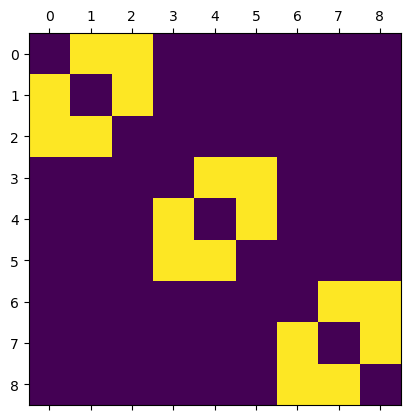

In [52]:
basis = fst.FockStates(2).restrict(U_inf=True)
new_basis = H[basis].to_block_diagonal_basis()
plt.matshow(np.real(H[new_basis].to_array()))

In [53]:
states = fst.FockStates(2)
states = states.restrict(U_inf=True)

OperUnit = H[states]

array = OperUnit.to_array()

E,phi = np.linalg.eigh(array)
E

array([-2., -2., -2., -2., -2., -2.,  4.,  4.,  4.])

# Local fermionic solution

In [54]:
import sympy as sp

sqrt = sp.sqrt

W = sp.Matrix([
    [1/sqrt(3),  1/sqrt(2),   1/sqrt(6)],
    [1/sqrt(3), -1/sqrt(2),   1/sqrt(6)],
    [1/sqrt(3),  0,          -2/sqrt(6)]
])


In [55]:
sigma,tau = show_solution(W)
Proj = (-2*P*c_up*P*P*a_up*P+1)*(-2*P*c_down*P*a_down*P+1)
even,odd = odd_even_split(tau)
tau_graded = (even>>1) + Proj*(odd>>1)

sigma1 = sigma
sigma2 = sigma>>1
tau1 = tau
tau2 = tau_graded

$\chi_1 = $ ($\displaystyle -2$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle - \frac{3}{2}$)$c^{†}_{0,↑}$$c_{0,↑}$ $+$ ($\displaystyle - \frac{3}{2}$)$c^{†}_{0,↓}$$c_{0,↓}$ $+$ ($\displaystyle 1$)$\hat{I}$ $+$ ($\displaystyle \frac{\sqrt{3}}{2}$)$c^{†}_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle - \frac{\sqrt{3}}{2}$)$c^{†}_{0,↑}$$c_{0,↓}$

$\chi_2 = $ ($\displaystyle - \frac{1}{4} - \frac{\sqrt{3} i}{4}$)$c^{†}_{0,↑}$$c_{0,↑}$ $+$ ($\displaystyle \frac{1}{4} + \frac{\sqrt{3} i}{4}$)$c^{†}_{0,↓}$$c_{0,↓}$ $+$ ($\displaystyle \frac{\sqrt{6}}{4} - \frac{\sqrt{2} i}{4}$)$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle \frac{\sqrt{6}}{4} - \frac{\sqrt{2} i}{4}$)$c_{0,↓}$ $+$ ($\displaystyle - \frac{\sqrt{2}}{4} - \frac{\sqrt{6} i}{4}$)$c^{†}_{0,↓}$$c_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle \frac{\sqrt{2}}{4} + \frac{\sqrt{6} i}{4}$)$c_{0,↑}$ $+$ ($\displaystyle - \frac{\sqrt{6}}{4} + \frac{\sqrt{2} i}{4}$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ ($\displaystyle \frac{\sqrt{6}}{4} - \frac{\sqrt{2} i}{4}$)$c^{†}_{0,↓}$ $+$ ($\displaystyle \frac{\sqrt{3}}{4} - \frac{i}{4}$)$c^{†}_{0,↓}$$c_{0,↑}$ $+$ ($\displaystyle \frac{\sqrt{2}}{4} + \frac{\sqrt{6} i}{4}$)$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$ $+$ ($\displaystyle \frac{\sqrt{2}}{4} + \frac{\sqrt{6} i}{4}$)$c^{†}_{0,↑}$ $+$ ($\displaystyle \frac{\sqrt{3}}{4} - \frac{i}{4}$)$c^{†}_{0,↑}$$c_{0,↓}$

In [56]:
chi1 = sigma1
chi2 = omega*chi1*tau1
chi3 = tau1*sigma2
chi4 = omega*chi3*tau2

In [57]:
H = np.conj(omega)*(~chi2)*chi3 + omega*(~chi3*chi2)
H.simplify()
H.sort()

### Check symmetry

In [58]:
Q = tau1*tau2
Q.simplify()

In [59]:
commutator = Q*H- H*Q
commutator.simplify()
commutator

$\hat{0}$

### Check Eigenvalues

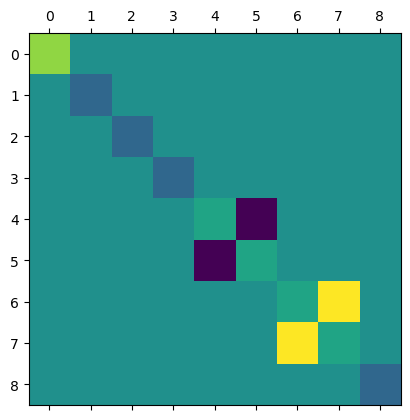

In [60]:
basis = fst.FockStates(2).restrict(U_inf=True)
new_basis = H[basis].to_block_diagonal_basis()
plt.matshow(np.real(H[new_basis].to_array()))

In [61]:
states = fst.FockStates(2)
states = states.restrict(U_inf=True)

OperUnit = H[states]

array = OperUnit.to_array()
array[4][8] /=2
array[8][4] /= 2

array[5][7] /= 2
array[7][5] /= 2
E,phi = np.linalg.eigh(array)
E

array([-1., -1., -1., -1., -1., -1.,  2.,  2.,  2.])